<div align="center">

# BKB Water Quality Analysis

### Exploratory analysis of water quality trends, site differences, and environmental indicators using Python

</div>

## Project Overview

This project analyzes water quality measurements collected across multiple sites from 1989 to 2019.

The goal was to understand whether key water quality indicators such as dissolved oxygen, salinity, pH, water temperature, and water clarity show signs of stress over time, and to identify a major problem supported by the data.

## Business Problem

**Is water quality showing a decline over time, and which measurable factors appear to be most associated with lower dissolved oxygen levels?**

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

if (NOTEBOOK_DIR / "data").exists():
    PROJECT_DIR = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "data").exists():
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = Path.cwd()

DATA = PROJECT_DIR / "data"
IMAGES = PROJECT_DIR / "images"
REPORTS = PROJECT_DIR / "reports"

IMAGES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: C:\Users\PrinceTova\Documents\Machine Learning\bkb-water-quality-analysis


## 1) Load the Dataset

The CSV file is loaded into a pandas DataFrame so the data can be inspected, cleaned, and analyzed.

In [2]:
df = pd.read_csv(DATA / "BKB_WaterQualityData_2020084.csv")
print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,Site_Id,Unit_Id,Read_Date,Salinity (ppt),Dissolved Oxygen (mg/L),pH (standard units),Secchi Depth (m),Water Depth (m),Water Temp (?C),Air Temp-Celsius,Air Temp (?F),Time (24:00),Field_Tech,DateVerified,WhoVerified,AirTemp (C),Year
0,Bay,NaN,1/3/1994,1.3,11.7,7.3,0.40,0.40,5.9,8.0,46.40,11:00,NaN,NaN,NaN,8.0,1994
1,Bay,NaN,1/31/1994,1.5,12.0,7.4,0.20,0.35,3.0,2.6,36.68,11:30,NaN,NaN,NaN,2.6,1994
2,Bay,NaN,2/7/1994,1.0,10.5,7.2,0.25,0.60,5.9,7.6,45.68,9:45,NaN,NaN,NaN,7.6,1994
3,Bay,NaN,2/23/1994,1.0,10.1,7.4,0.35,0.50,10.0,2.7,36.86,NaN,NaN,NaN,NaN,2.7,1994
4,Bay,NaN,2/28/1994,1.0,12.6,7.2,0.20,0.40,1.6,0.0,32.00,10:30,NaN,NaN,NaN,0.0,1994


## 2) First Look at the Data

The following checks confirm that the dataset loaded correctly and help identify its overall structure.

In [3]:
display(df.tail())
print("Shape:", df.shape)
print("Columns:")
display(pd.DataFrame({"Column Names": df.columns}))
print("Data types:")
display(df.dtypes.to_frame(name="Dtype"))
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False).to_frame(name="Missing Values"))
print("Duplicate rows:", df.duplicated().sum())

,Site_Id,Unit_Id,Read_Date,Salinity (ppt),Dissolved Oxygen (mg/L),pH (standard units),Secchi Depth (m),Water Depth (m),Water Temp (?C),Air Temp-Celsius,Air Temp (?F),Time (24:00),Field_Tech,DateVerified,WhoVerified,AirTemp (C),Year
2366,Bay,NaN,10/11/2018,1.9,5.0,7.0,4.00,1.2,25.0,NaN,78.0,09:30,Sue Poe,11/13/2019,Christine Folks,25.555556,2018
2367,Bay,NaN,10/24/2018,0.0,9.0,7.0,0.30,0.6,18.0,NaN,58.0,09:30,Sue Poe,11/13/2019,Christine Folks,14.444444,2018
2368,Bay,NaN,10/28/2018,0.9,2.9,7.0,0.40,0.9,13.0,NaN,49.0,09:20,Sue Poe,11/13/2019,Christine Folks,9.444444,2018
2369,Bay,NaN,11/7/2018,1.7,NaN,7.0,0.45,0.9,20.0,NaN,65.0,09:45,Sue Poe,11/13/2019,Christine Folks,18.333333,2018
2370,Bay,NaN,12/11/2018,0.1,NaN,7.0,0.10,0.1,10.0,NaN,42.0,09:40,Sue Poe,11/13/2019,Christine Folks,5.555556,2018


Shape: (2371, 17)
Columns:


,Column Names
0,Site_Id
1,Unit_Id
2,Read_Date
3,Salinity (ppt)
4,Dissolved Oxygen (mg/L)
5,pH (standard units)
6,Secchi Depth (m)
7,Water Depth (m)
8,Water Temp (?C)
9,Air Temp-Celsius


Data types:


,Dtype
Site_Id,object
Unit_Id,object
Read_Date,object
Salinity (ppt),float64
Dissolved Oxygen (mg/L),float64
pH (standard units),float64
Secchi Depth (m),float64
Water Depth (m),float64
Water Temp (?C),float64
Air Temp-Celsius,float64


Missing values by column:


,Missing Values
Unit_Id,2339
Air Temp-Celsius,2286
WhoVerified,1918
DateVerified,1918
Dissolved Oxygen (mg/L),851
Salinity (ppt),130
Water Temp (?C),121
pH (standard units),95
Secchi Depth (m),73
Water Depth (m),71


Duplicate rows: 0


## 3) Data Cleaning and Preparation

This step standardizes the date fields and creates a clean year variable for trend analysis.

Five rows contain an invalid year code (`1899`) and no usable date, so they are excluded from time-based calculations.

In [4]:
df["Read_Date"] = pd.to_datetime(df["Read_Date"], errors="coerce")
df["AnalysisYear"] = df["Read_Date"].dt.year

# Use the Year column only where it is valid and Read_Date is missing
mask = df["AnalysisYear"].isna() & (df["Year"] >= 1900)
df.loc[mask, "AnalysisYear"] = df.loc[mask, "Year"]
df["AnalysisYear"] = df["AnalysisYear"].astype("Int64")

analysis_df = df[df["AnalysisYear"].notna()].copy()
analysis_df["Decade"] = (analysis_df["AnalysisYear"].astype(int) // 10) * 10

print("Cleaning completed.")
print("Invalid year rows excluded from time-based analysis:", (df["Year"] < 1900).sum())
display(analysis_df.head())

Cleaning completed.
Invalid year rows excluded from time-based analysis: 5


,Site_Id,Unit_Id,Read_Date,Salinity (ppt),Dissolved Oxygen (mg/L),pH (standard units),Secchi Depth (m),Water Depth (m),Water Temp (?C),Air Temp-Celsius,Air Temp (?F),Time (24:00),Field_Tech,DateVerified,WhoVerified,AirTemp (C),Year,AnalysisYear,Decade
0,Bay,NaN,1994-01-03,1.3,11.7,7.3,0.40,0.40,5.9,8.0,46.40,11:00,NaN,NaN,NaN,8.0,1994,1994,1990
1,Bay,NaN,1994-01-31,1.5,12.0,7.4,0.20,0.35,3.0,2.6,36.68,11:30,NaN,NaN,NaN,2.6,1994,1994,1990
2,Bay,NaN,1994-02-07,1.0,10.5,7.2,0.25,0.60,5.9,7.6,45.68,9:45,NaN,NaN,NaN,7.6,1994,1994,1990
3,Bay,NaN,1994-02-23,1.0,10.1,7.4,0.35,0.50,10.0,2.7,36.86,NaN,NaN,NaN,NaN,2.7,1994,1994,1990
4,Bay,NaN,1994-02-28,1.0,12.6,7.2,0.20,0.40,1.6,0.0,32.00,10:30,NaN,NaN,NaN,0.0,1994,1994,1990


## 4) Data Interpretation

This summary describes the size, scope, and quality of the cleaned dataset.

In [5]:
total_rows = len(df)
total_cols = df.shape[1]
missing_cells = int(df.isna().sum().sum())
duplicates = int(df.duplicated().sum())
year_min = int(analysis_df["AnalysisYear"].min())
year_max = int(analysis_df["AnalysisYear"].max())
sites = df["Site_Id"].nunique(dropna=True)

summary = pd.DataFrame({
    "Metric": [
        "Records",
        "Columns",
        "Missing Cells",
        "Duplicate Rows",
        "Unique Sites",
        "Years Covered",
        "Mean Dissolved Oxygen (mg/L)",
        "Mean Water Temp (°C)",
        "Mean pH",
        "Mean Salinity (ppt)",
        "Mean Secchi Depth (m)",
        "Correlation: DO vs Water Temp",
        "Correlation: DO vs Year"
    ],
    "Value": [
        total_rows,
        total_cols,
        missing_cells,
        duplicates,
        sites,
        f"{year_min}–{year_max}",
        round(df["Dissolved Oxygen (mg/L)"].mean(), 2),
        round(df["Water Temp (?C)"].mean(), 2),
        round(df["pH (standard units)"].mean(), 2),
        round(df["Salinity (ppt)"].mean(), 2),
        round(df["Secchi Depth (m)"].mean(), 2),
        round(df["Dissolved Oxygen (mg/L)"].corr(df["Water Temp (?C)"]), 2),
        round(df["Dissolved Oxygen (mg/L)"].corr(df["Year"]), 2)
    ]
})

display(summary)

print("Missing values in the most important measurement columns:")
display(df[[
    "Salinity (ppt)",
    "Dissolved Oxygen (mg/L)",
    "pH (standard units)",
    "Secchi Depth (m)",
    "Water Depth (m)",
    "Water Temp (?C)"
]].isna().sum().sort_values(ascending=False).to_frame(name="Missing Values"))

,Metric,Value
0,Records,2371
1,Columns,18
2,Missing Cells,9986
3,Duplicate Rows,0
4,Unique Sites,6
5,Years Covered,1989–2019
6,Mean Dissolved Oxygen (mg/L),6.65
7,Mean Water Temp (°C),18.06
8,Mean pH,7.17
9,Mean Salinity (ppt),0.72


Missing values in the most important measurement columns:


,Missing Values
Dissolved Oxygen (mg/L),851
Salinity (ppt),130
Water Temp (?C),121
pH (standard units),95
Secchi Depth (m),73
Water Depth (m),71


## 5) Yearly Water Quality Trends

This chart compares yearly dissolved oxygen and water temperature. A decline in oxygen together with warmer water can indicate environmental stress.

,AnalysisYear,Records,MeanDO,MeanWaterTemp,MeanpH,MeanSalinity,MeanSecchi
0,1989,17,7.458333,20.823529,8.235294,NaN,0.252941
1,1990,37,9.426389,16.540541,7.344595,3.120588,0.288243
2,1991,43,9.642857,16.174419,7.625581,2.025714,0.287073
3,1992,45,9.611364,15.636364,7.452222,3.762222,0.285000
4,1993,42,9.578049,16.354762,7.305000,2.875000,0.341667


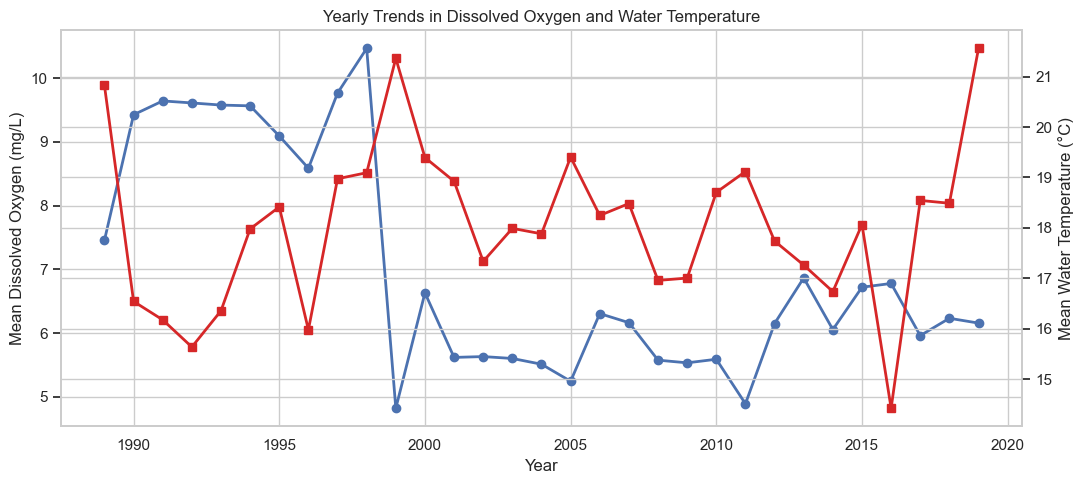

In [8]:
yearly = analysis_df.groupby("AnalysisYear").agg(
    Records=("AnalysisYear", "size"),
    MeanDO=("Dissolved Oxygen (mg/L)", "mean"),
    MeanWaterTemp=("Water Temp (?C)", "mean"),
    MeanpH=("pH (standard units)", "mean"),
    MeanSalinity=("Salinity (ppt)", "mean"),
    MeanSecchi=("Secchi Depth (m)", "mean"),
).reset_index()

display(yearly.head())

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(yearly["AnalysisYear"], yearly["MeanDO"], marker="o", linewidth=2, label="Mean Dissolved Oxygen")
ax1.set_xlabel("Year")
ax1.set_ylabel("Mean Dissolved Oxygen (mg/L)")
ax2 = ax1.twinx()
ax2.plot(yearly["AnalysisYear"], yearly["MeanWaterTemp"], marker="s", linewidth=2, color="tab:red", label="Mean Water Temperature")
ax2.set_ylabel("Mean Water Temperature (°C)")
ax1.set_title("Yearly Trends in Dissolved Oxygen and Water Temperature")
fig.tight_layout()
fig.savefig(IMAGES / "yearly_trends.png", dpi=200, bbox_inches="tight")
plt.show()

## 6) Correlation Heatmap

The heatmap shows which variables move together. This helps identify the strongest potential drivers of low dissolved oxygen.

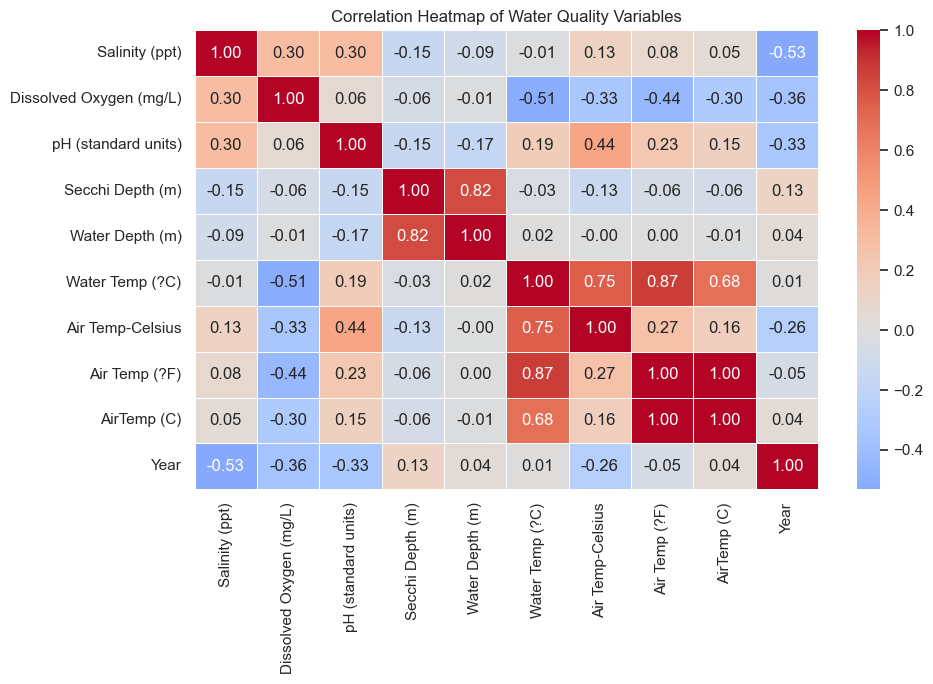

In [9]:
num_cols = [
    "Salinity (ppt)",
    "Dissolved Oxygen (mg/L)",
    "pH (standard units)",
    "Secchi Depth (m)",
    "Water Depth (m)",
    "Water Temp (?C)",
    "Air Temp-Celsius",
    "Air Temp (?F)",
    "AirTemp (C)",
    "Year"
]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.4, ax=ax)
ax.set_title("Correlation Heatmap of Water Quality Variables")
fig.tight_layout()
fig.savefig(IMAGES / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 7) Dissolved Oxygen versus Water Temperature

This scatter plot tests whether warmer water is associated with lower dissolved oxygen.

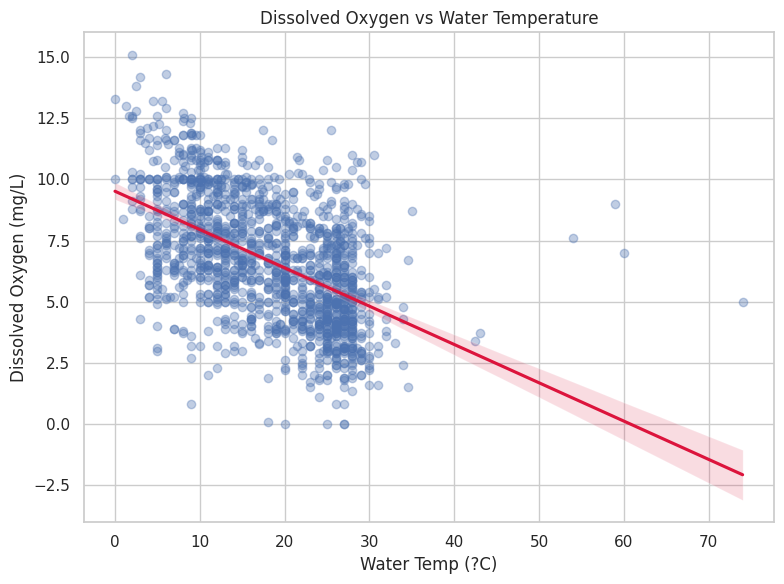

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Water Temp (?C)",
    y="Dissolved Oxygen (mg/L)",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "crimson"},
    ax=ax
)
ax.set_title("Dissolved Oxygen vs Water Temperature")
fig.tight_layout()
fig.savefig(IMAGES / "dissolved_oxygen_vs_water_temp.png", dpi=200, bbox_inches="tight")
plt.show()

## 8) Site-Level Comparison

This chart compares average dissolved oxygen across the monitoring sites.

,Site_Id,Readings,MeanDO,MeanWaterTemp,MeanpH,MeanSecchi
1,B,437,5.340867,18.312833,7.261928,0.298425
0,A,434,5.416033,18.598305,6.884300,0.625420
3,C,264,5.443284,18.216598,7.436000,0.477040
4,D,440,6.289419,18.257452,6.786256,0.909207
2,Bay,794,7.599752,17.466984,7.391796,0.396758
5,d,1,NaN,30.500000,7.000000,0.800000


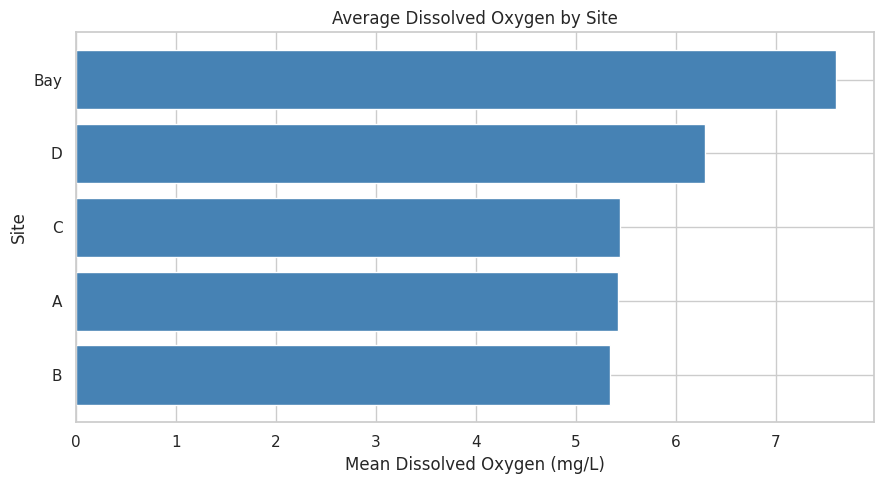

In [9]:
site_stats = df.groupby("Site_Id", as_index=False).agg(
    Readings=("Site_Id", "size"),
    MeanDO=("Dissolved Oxygen (mg/L)", "mean"),
    MeanWaterTemp=("Water Temp (?C)", "mean"),
    MeanpH=("pH (standard units)", "mean"),
    MeanSecchi=("Secchi Depth (m)", "mean"),
).sort_values("MeanDO", ascending=True)

display(site_stats)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(site_stats["Site_Id"].astype(str), site_stats["MeanDO"], color="steelblue")
ax.set_xlabel("Mean Dissolved Oxygen (mg/L)")
ax.set_ylabel("Site")
ax.set_title("Average Dissolved Oxygen by Site")
fig.tight_layout()
fig.savefig(IMAGES / "mean_do_by_site.png", dpi=200, bbox_inches="tight")
plt.show()

## 9) Dissolved Oxygen by Decade

The boxplot shows how dissolved oxygen is distributed across decades and whether later decades tend to have lower readings.

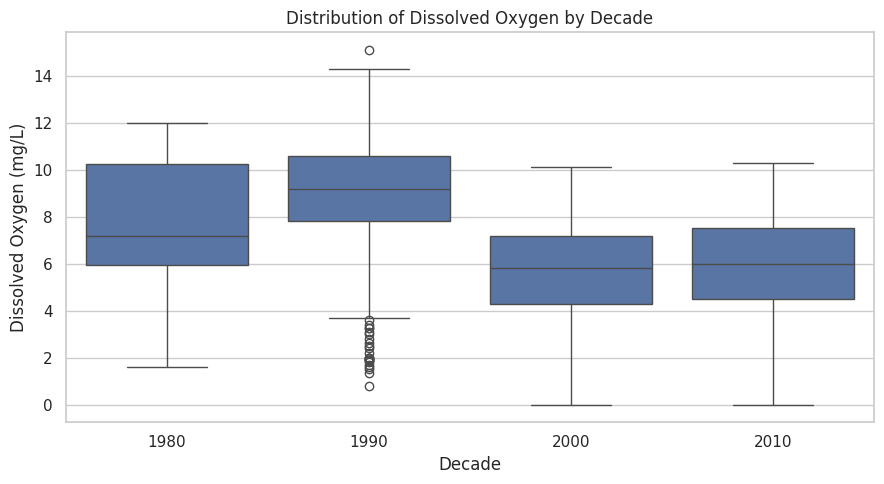

In [10]:
analysis_df["Decade"] = (analysis_df["AnalysisYear"].astype(int) // 10) * 10

fig, ax = plt.subplots(figsize=(9, 5))
decade_order = sorted(analysis_df["Decade"].dropna().unique())
sns.boxplot(data=analysis_df, x="Decade", y="Dissolved Oxygen (mg/L)", order=decade_order, ax=ax)
ax.set_xlabel("Decade")
ax.set_ylabel("Dissolved Oxygen (mg/L)")
ax.set_title("Distribution of Dissolved Oxygen by Decade")
fig.tight_layout()
fig.savefig(IMAGES / "do_by_decade.png", dpi=200, bbox_inches="tight")
plt.show()

## 10) Missing Values Overview

This chart highlights which variables have the largest amount of missing data and may need stronger monitoring or data collection practices.

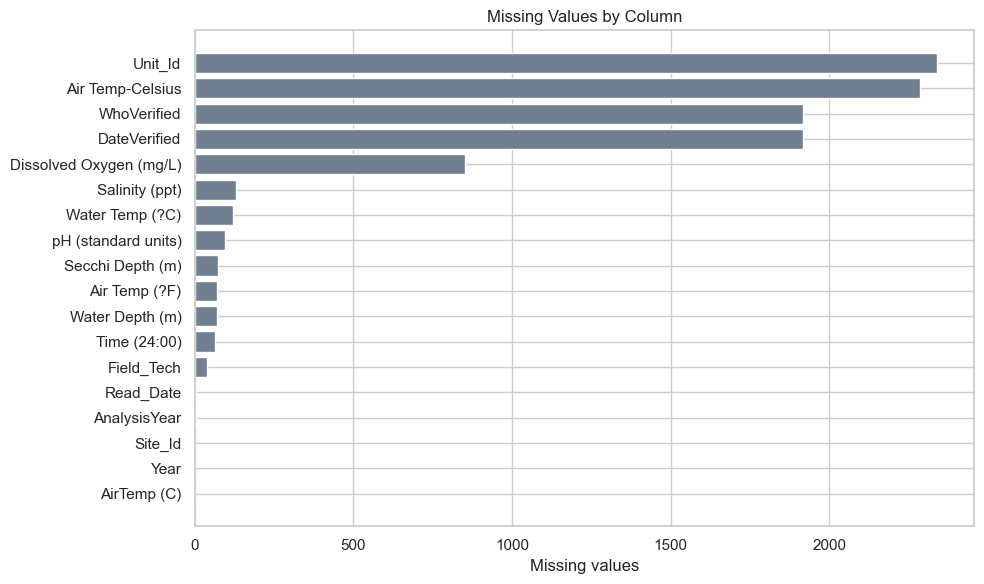

In [6]:
missing_by_col = df.isna().sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing_by_col.index, missing_by_col.values, color="slategray")
ax.set_xlabel("Missing values")
ax.set_title("Missing Values by Column")
fig.tight_layout()
fig.savefig(IMAGES / "missing_values_by_column.png", dpi=200, bbox_inches="tight")
plt.show()

## 11) Problem Identification and Root Cause Analysis

### Main Problem

The data shows a **decline in dissolved oxygen over time**, especially when comparing the 1990s with the 2010s. The average dissolved oxygen level fell from **8.91 mg/L** in the 1990s to **6.10 mg/L** in the 2010s, a decline of **2.81 mg/L** or about **31.5%**.

### Root Cause Evidence

- Dissolved oxygen has a strong negative relationship with water temperature (**r = -0.51**).
- Dissolved oxygen also declines over time (**r = -0.36** with Year).
- The lowest-average site has much weaker oxygen conditions than the highest-average site.
- A large share of dissolved oxygen readings are below 5 mg/L, which can signal stress for aquatic life.

### Secondary Data Quality Issue

The dataset also contains substantial missing values in several columns, especially dissolved oxygen and verification fields. That means monitoring coverage can be improved alongside the environmental response.

## 12) Recommendations

1. Increase monitoring during warm periods and at lower-oxygen sites.
2. Investigate site-specific factors that may be reducing dissolved oxygen.
3. Improve data collection consistency so missing values are reduced.
4. Track dissolved oxygen and temperature together over time to detect stress earlier.
5. Use the low-oxygen findings to prioritize restoration or mitigation actions.

## Conclusion

The analysis suggests that water quality has become less favorable over time, with dissolved oxygen declining in later years and showing a clear inverse relationship with water temperature. The results support a focused monitoring and management response.


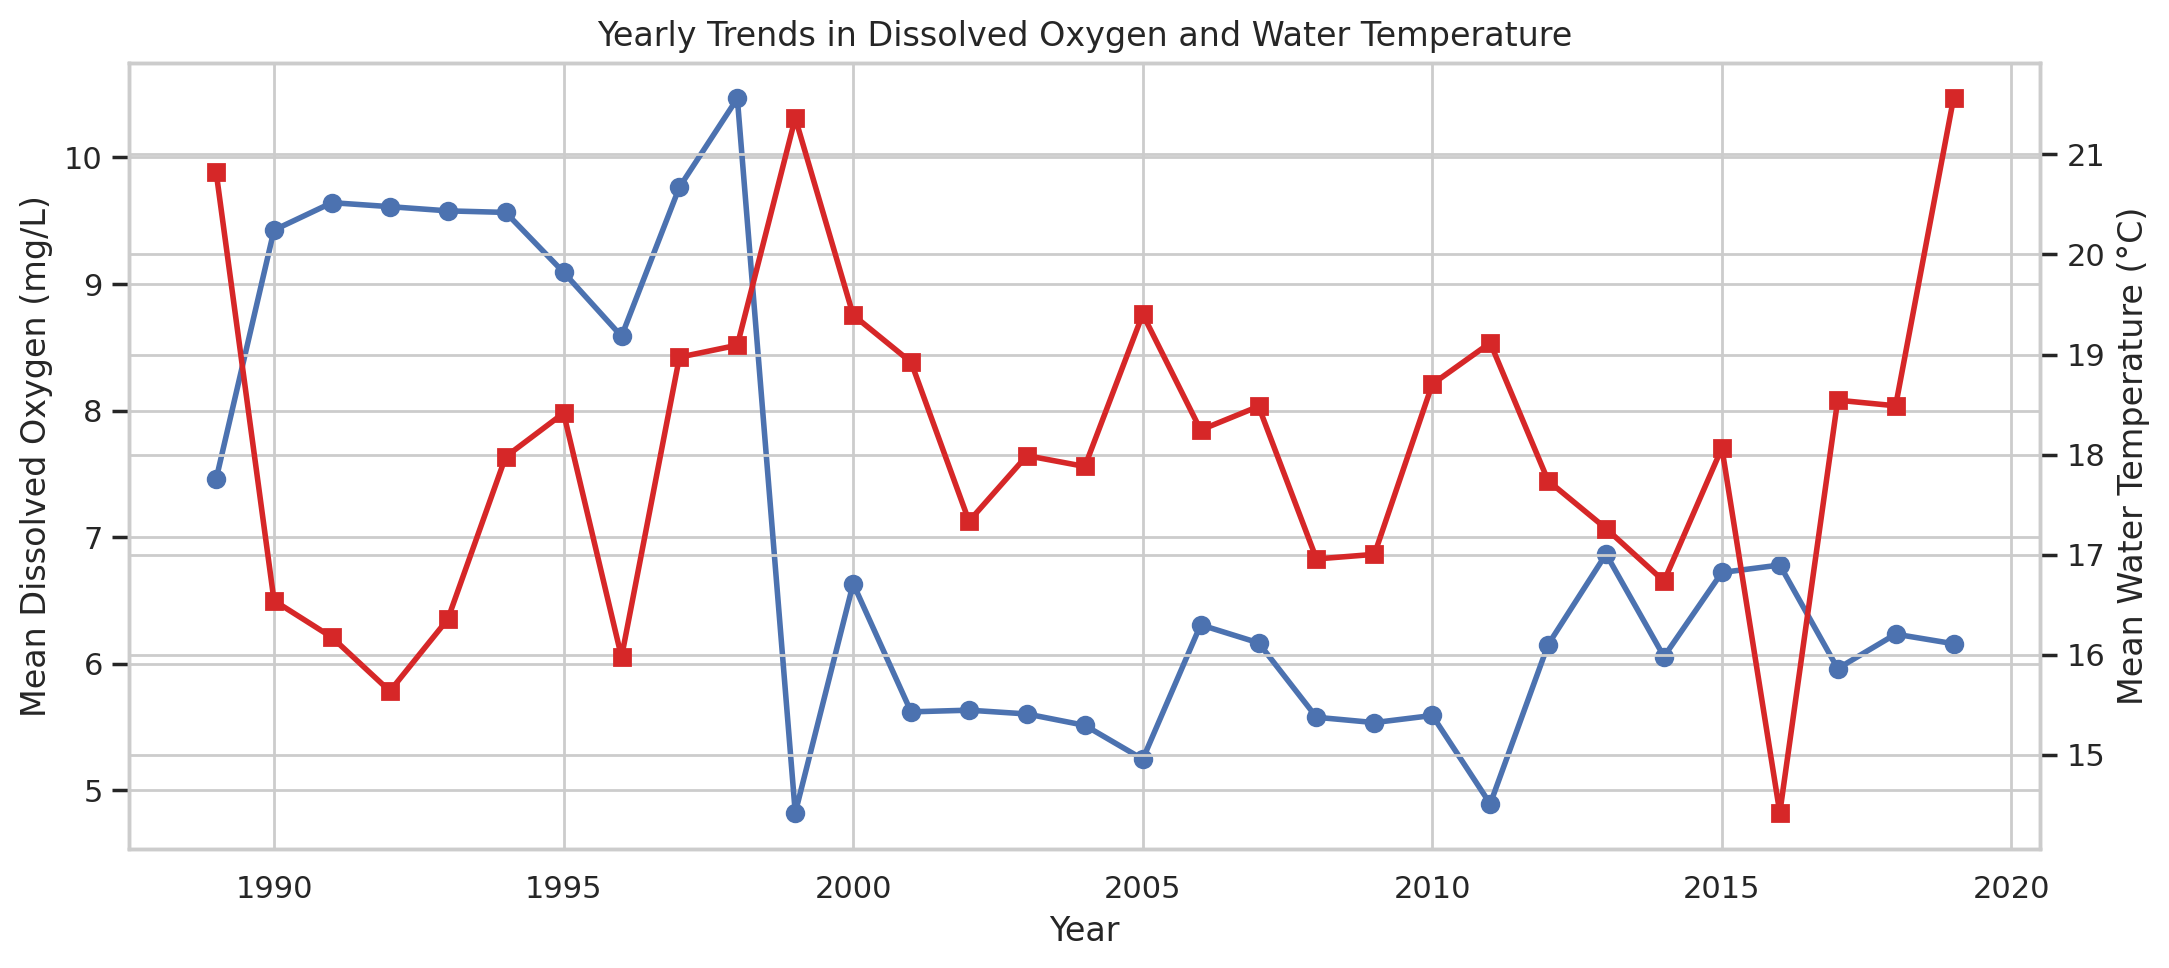
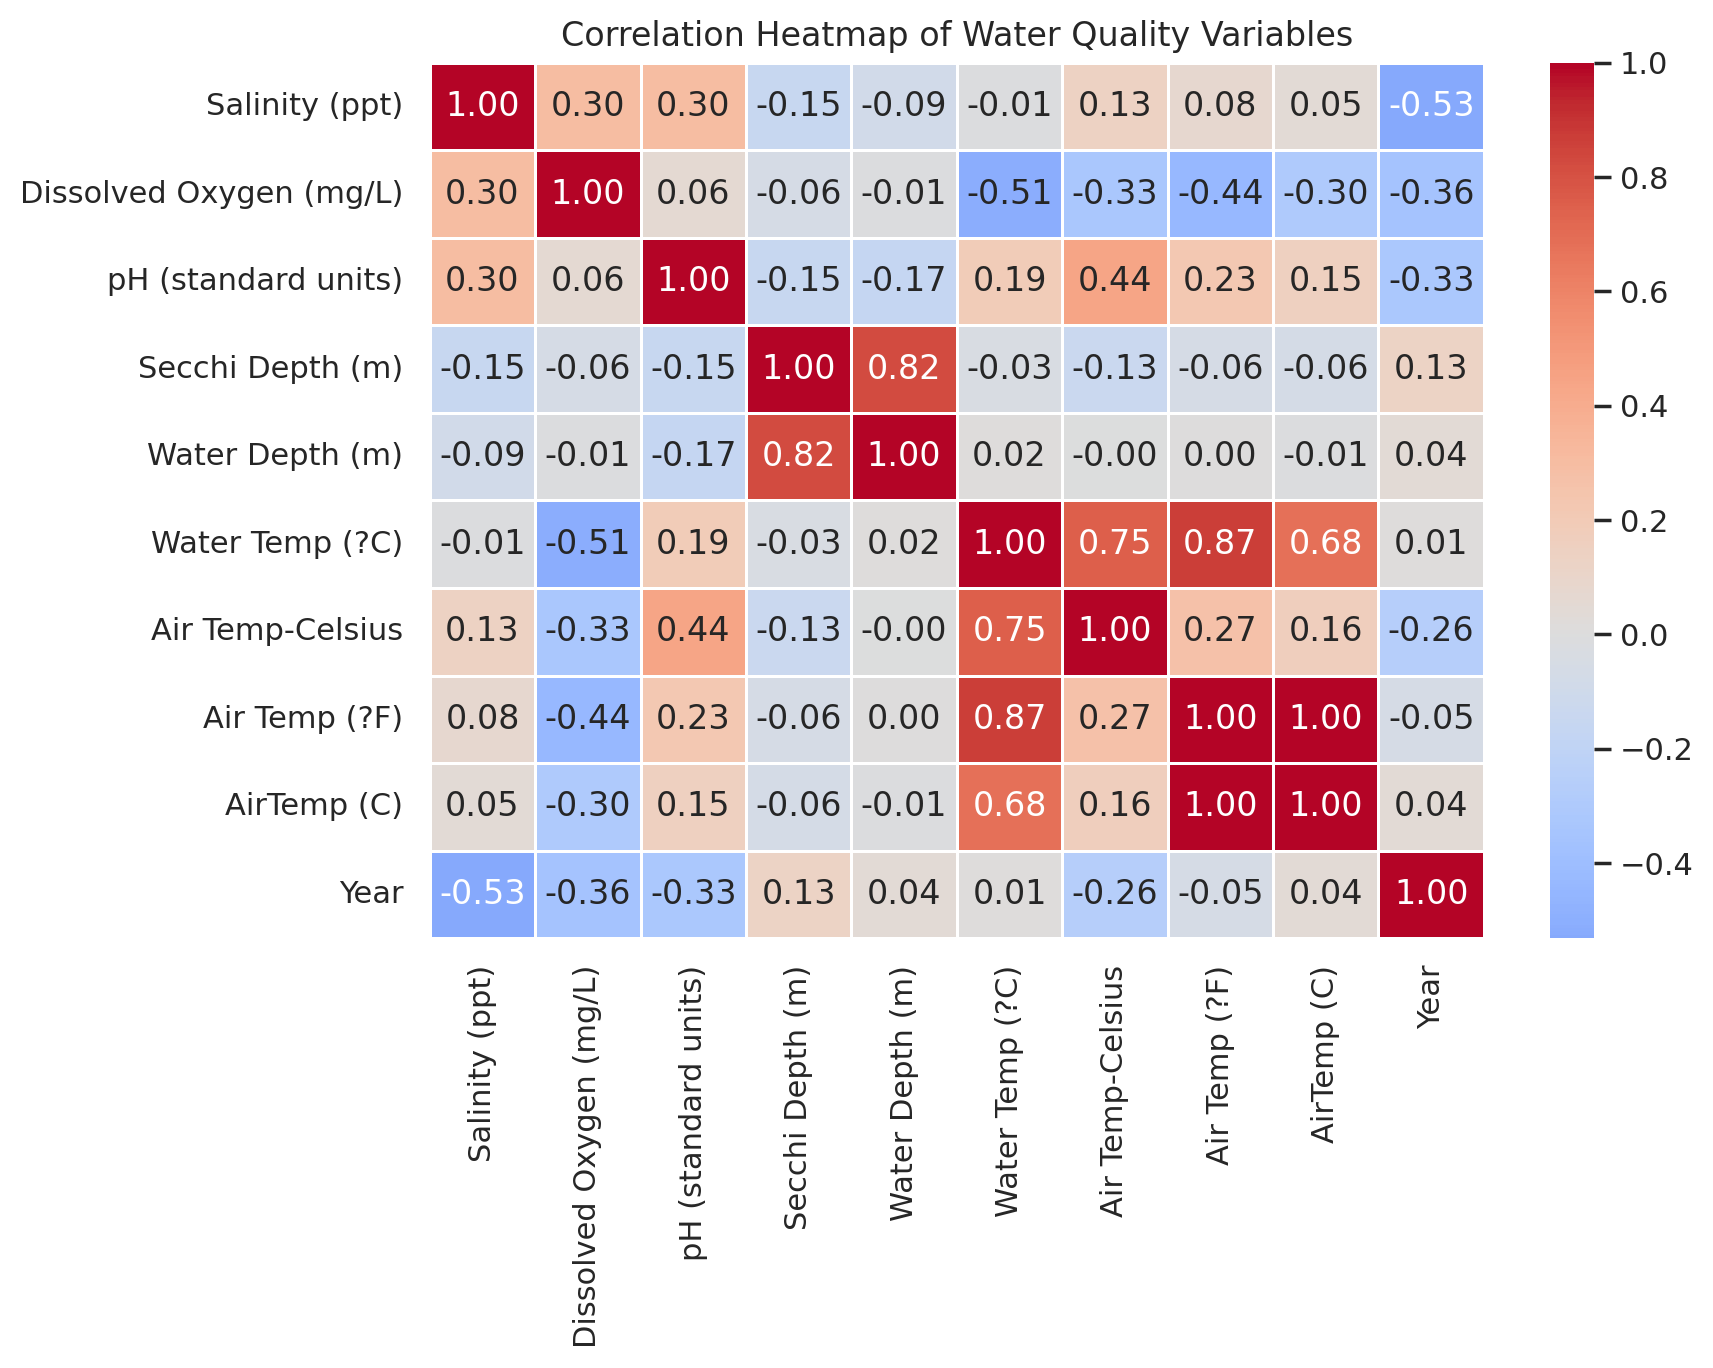
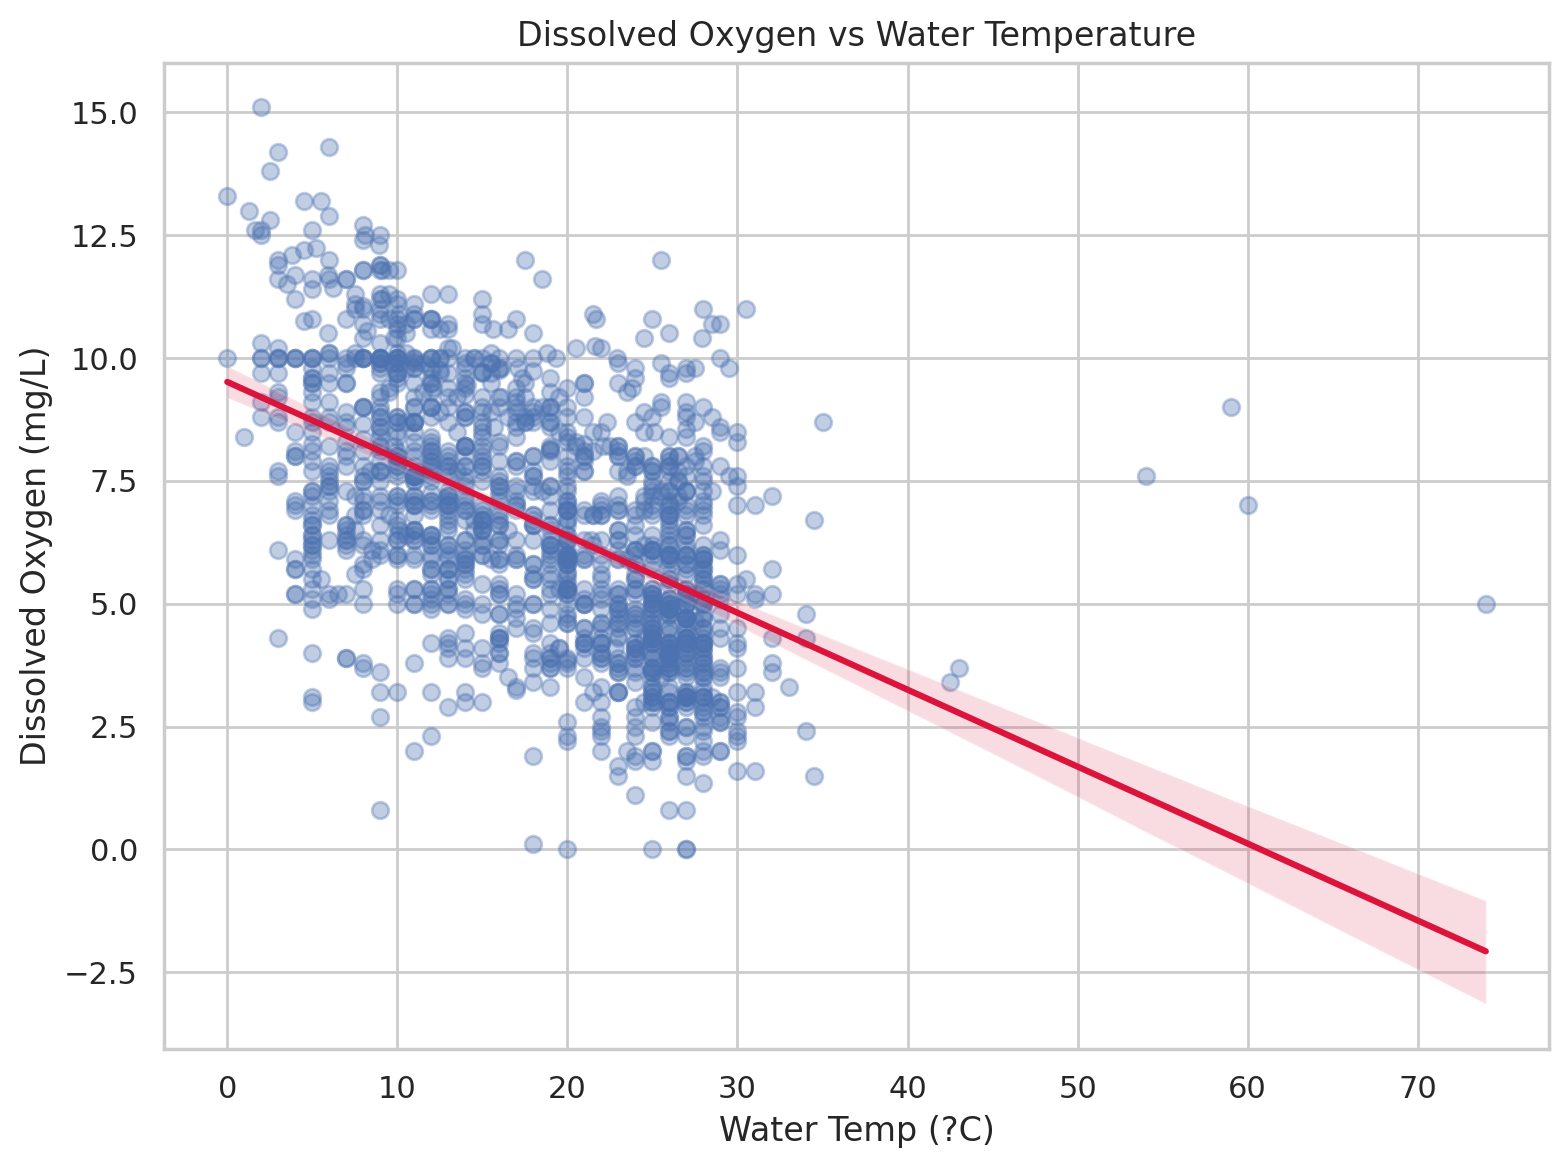
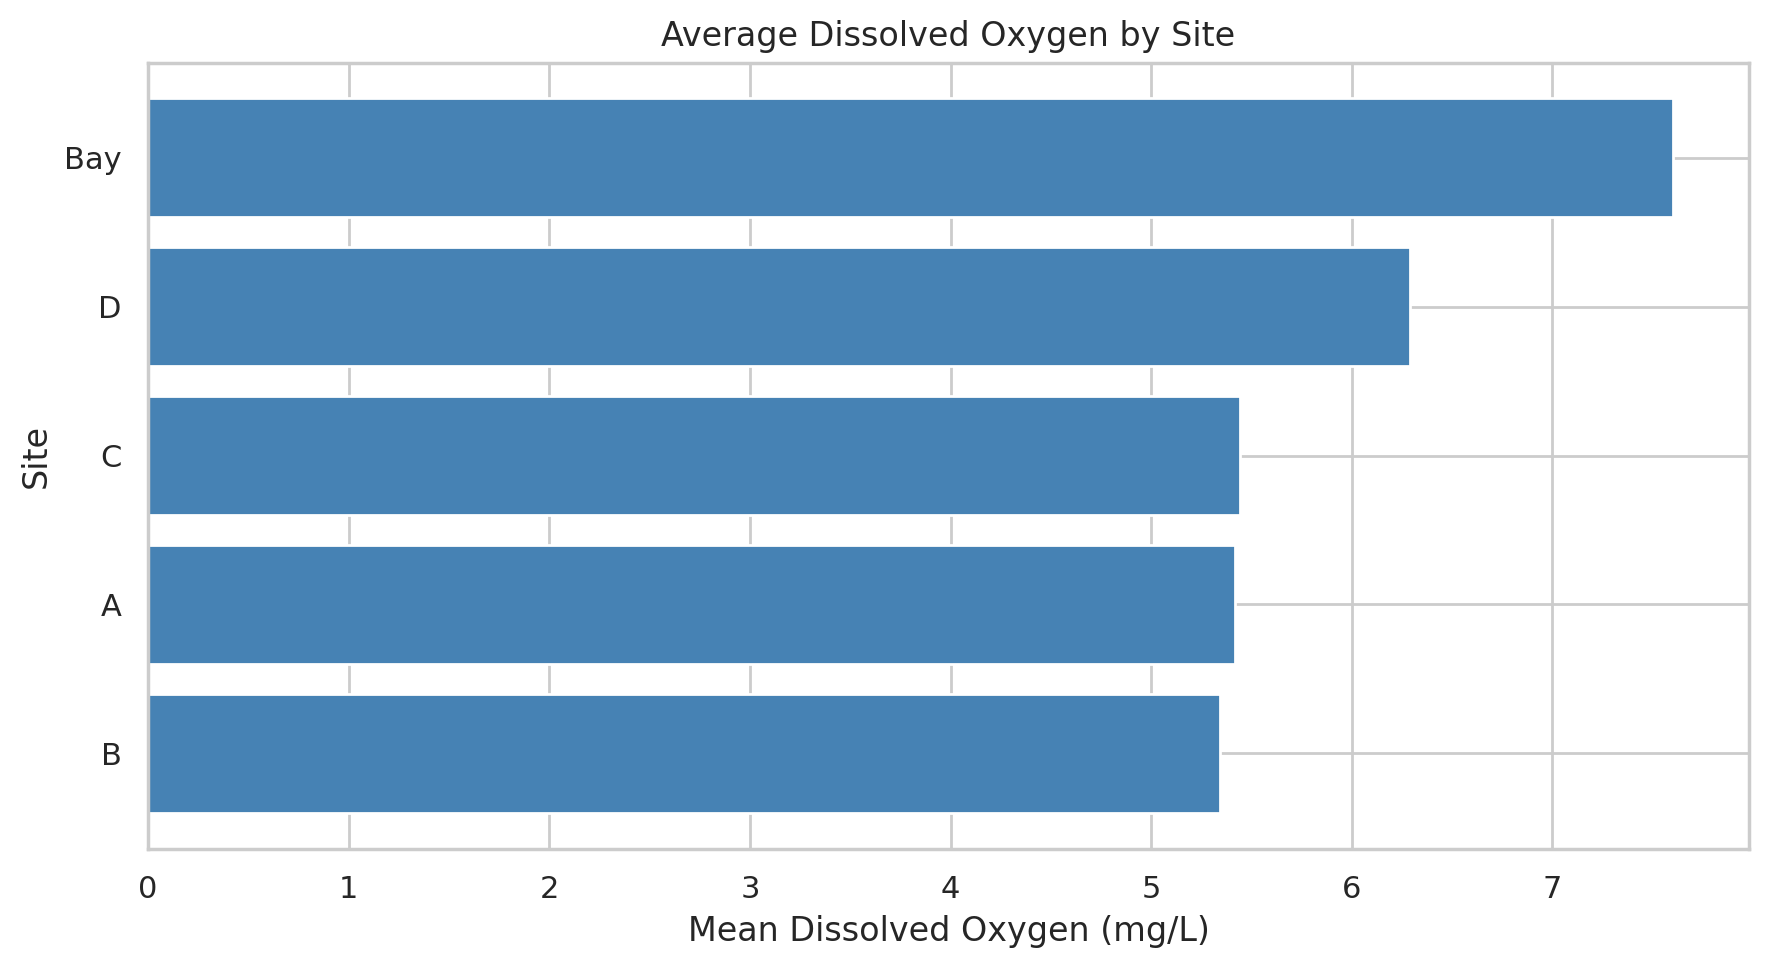
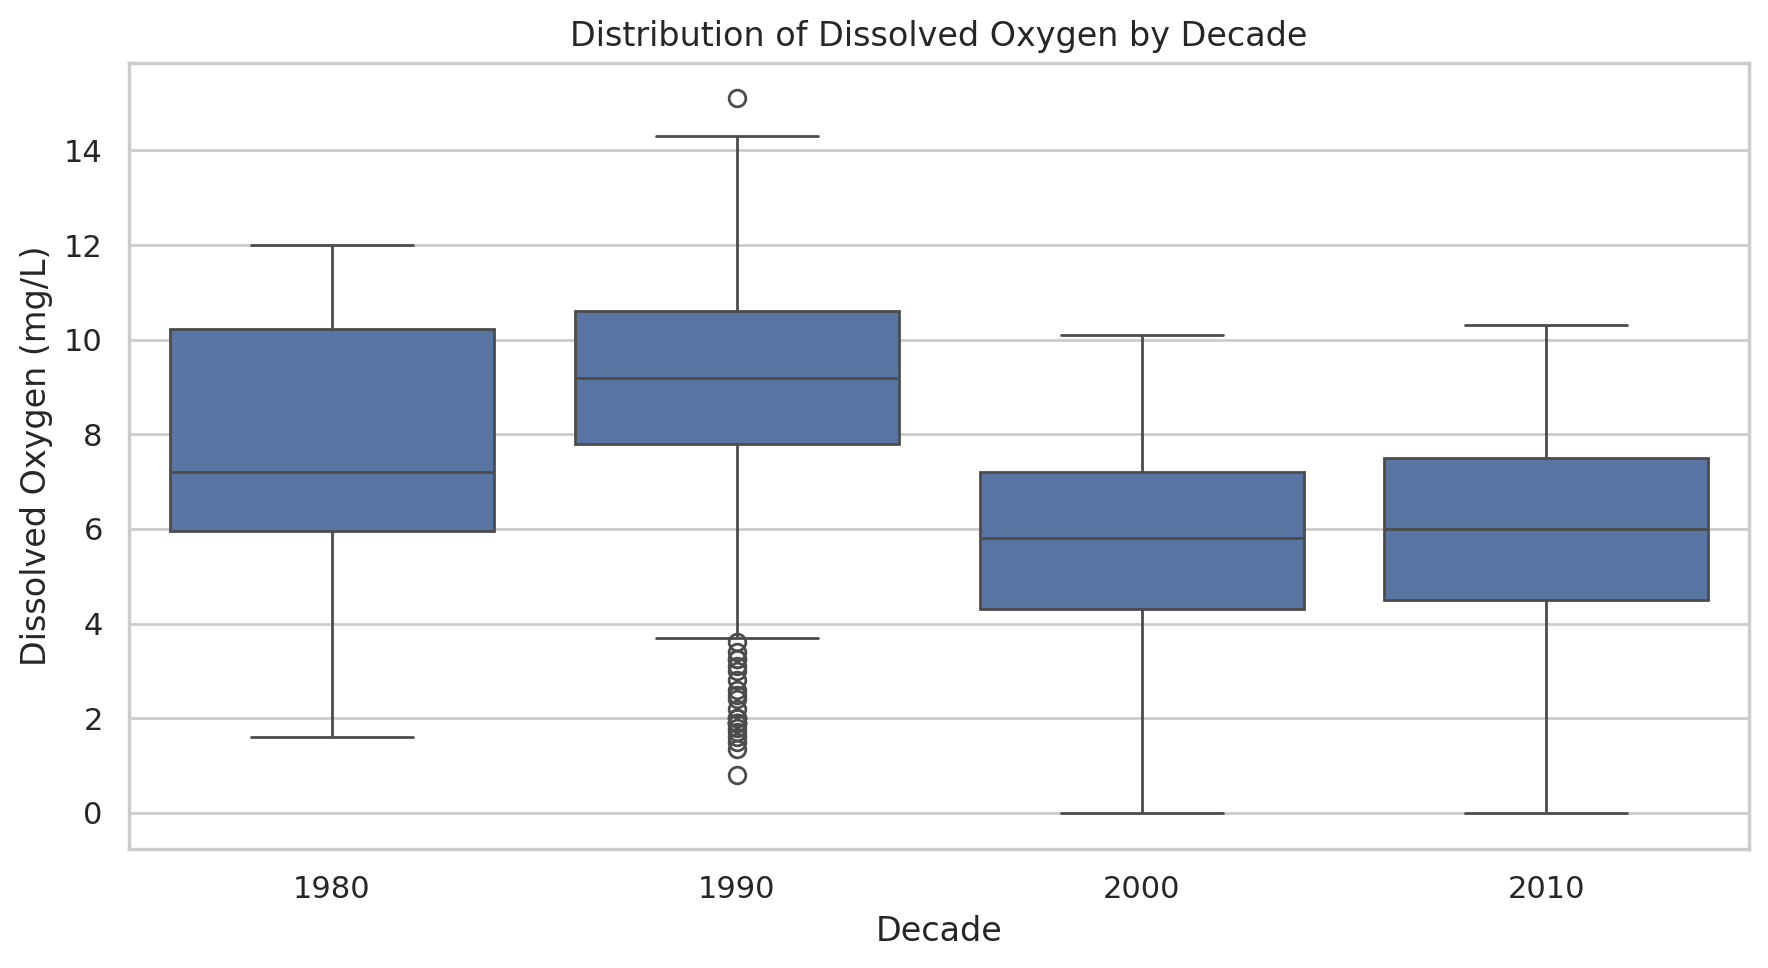
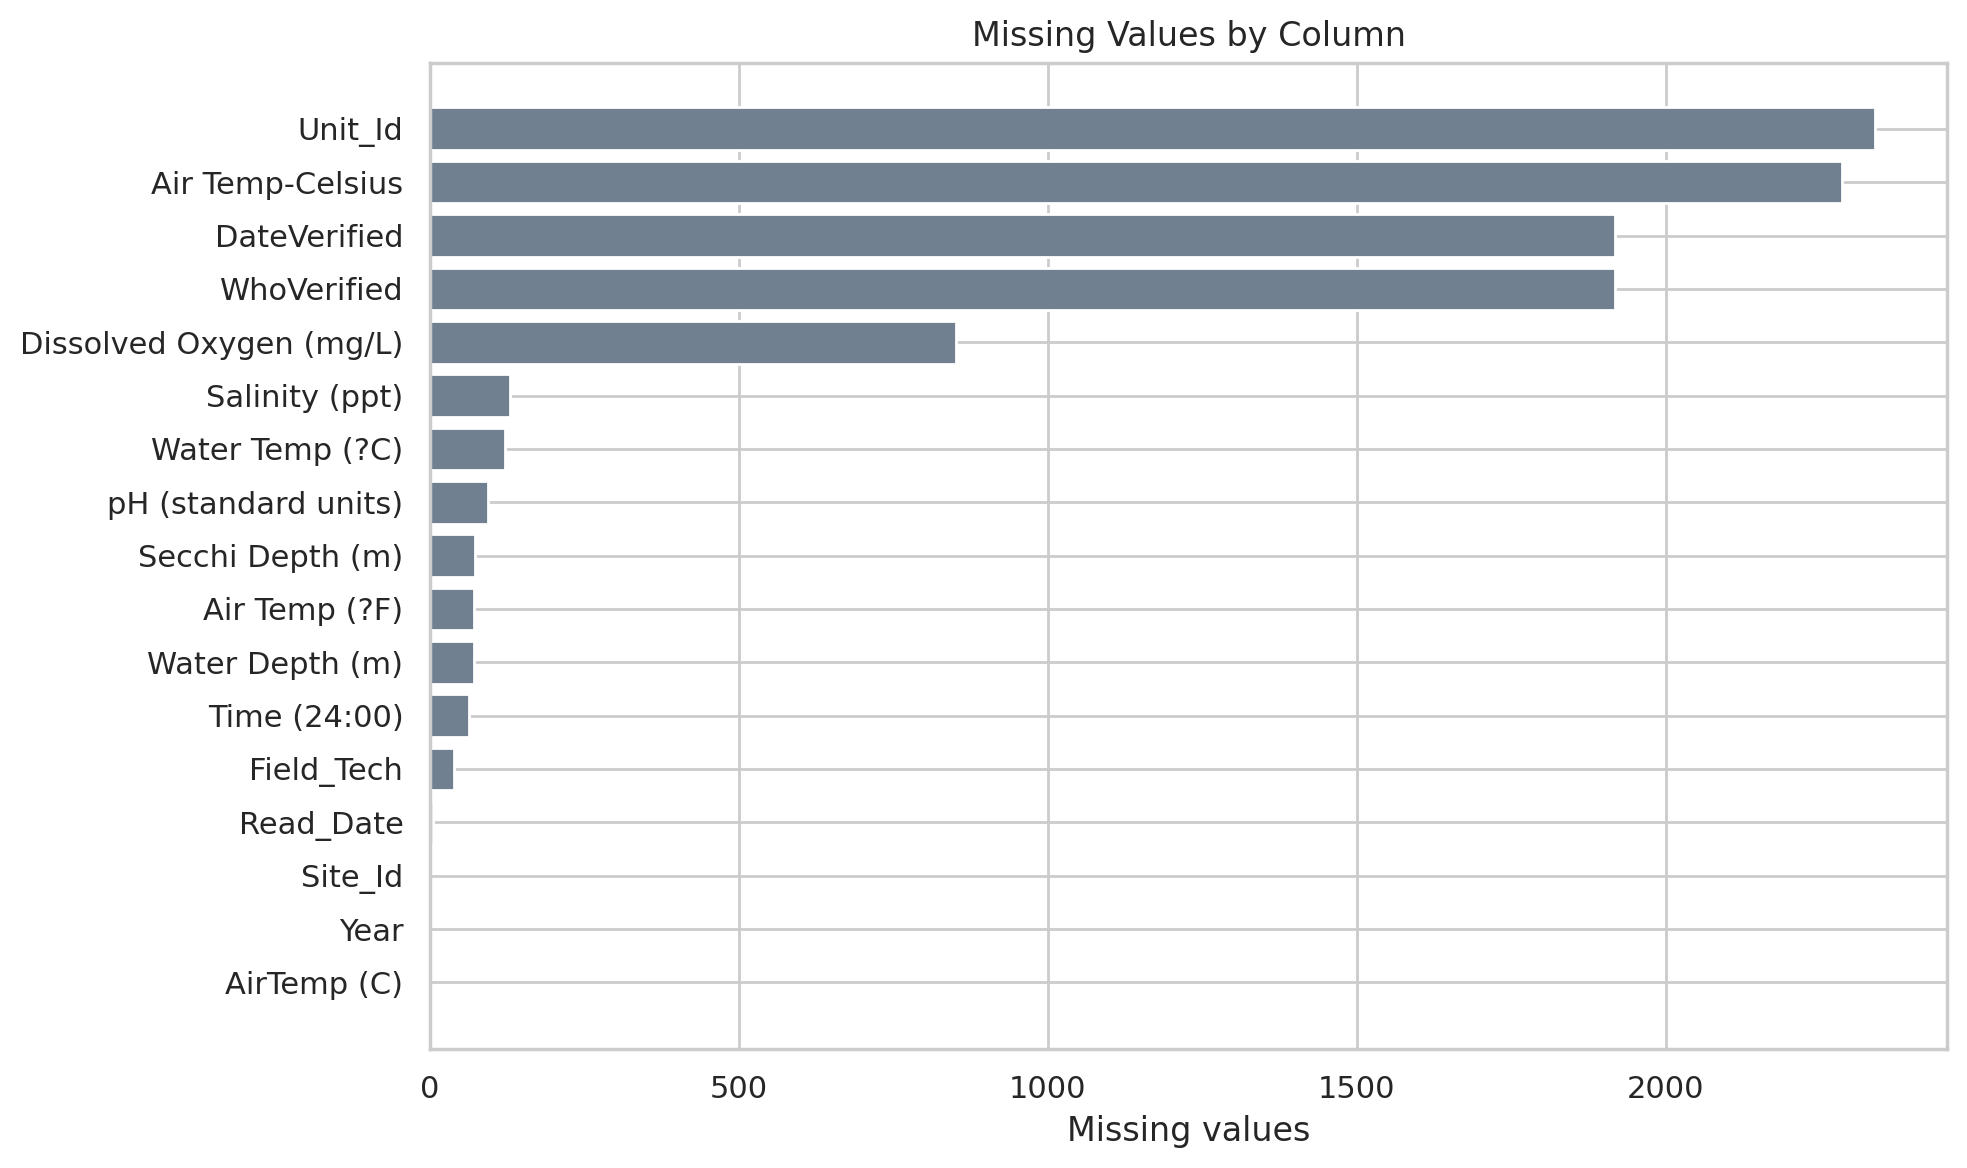

In [7]:
with open(REPORTS / "bkb_water_quality_report.html", "r", encoding="utf-8") as f:
    display(HTML(f.read()))